Quantum Monte Carlo Simulation

In [1]:
from scipy.stats import norm, lognorm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import transpile


In [3]:
# Runs on simulator #
def quantum_normal_sim(mu=0, sigma=1, n_qubits=100):
    # build circuit
    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))  # Put all qubits in superposition
    qc.measure(range(n_qubits), range(n_qubits))

    # run on sim
    simulator = AerSimulator()
    result = simulator.run(qc, shots=1, memory=True).result()
    bitstring = result.get_memory()[0]
    
    # count 1s
    count_ones = bitstring.count('1')
    
    # binomial --> normal using
    # Z = (X - np) / sqrt(npq)
    n = n_qubits
    p = 0.5
    mean_bin = n * p
    std_bin = np.sqrt(n * p * (1 - p))
    
    # Standardize to N(0, 1)
    z = (count_ones - mean_bin) / std_bin
    
    # Scale to user-defined mu and sigma
    return (z * sigma) + mu

# test
print(f"Quantum Normal Sample: {quantum_normal_sim()}")

Quantum Normal Sample: -1.4


In [4]:
# # runs on real quantum machines, make sure IBM cloud info is saved
# def quantum_normal(mu=0, sigma=1, n_qubits=100):
#     service = QiskitRuntimeService()
#     backend = service.least_busy(operational=True, simulator=False)
#     print(f"Running on backend: {backend.name}")

#     # build circuit
#     qc = QuantumCircuit(n_qubits, n_qubits)
#     qc.h(range(n_qubits))
#     qc.measure(range(n_qubits), range(n_qubits))

#     # Transpile for hardware
#     transpiled_circuit = transpile(qc, backend=backend, optimization_level=3)

#     # Run using Sampler V2 (shots=1)
#     sampler = Sampler(mode=backend)
#     pubs = [(transpiled_circuit, None, 1)]
#     job = sampler.run(pubs)
#     job_result = job.result()
   
#     creg_data = next(iter(job_result[0].data.values()))
    
#     # Extract the first shot's bitstring
#     bitstring = creg_data.get_bitstrings()[0]

#     # count 1s
#     count_ones = bitstring.count('1')

#     # make normal
#     n = n_qubits
#     p = 0.5
#     mean_bin = n * p
#     std_bin = np.sqrt(n * p * (1 - p))
#     z = (count_ones - mean_bin) / std_bin
#     return (z * sigma) + mu

# # Example Usage
# print(f"Quantum Normal Sample (real backend): {quantum_normal()}")


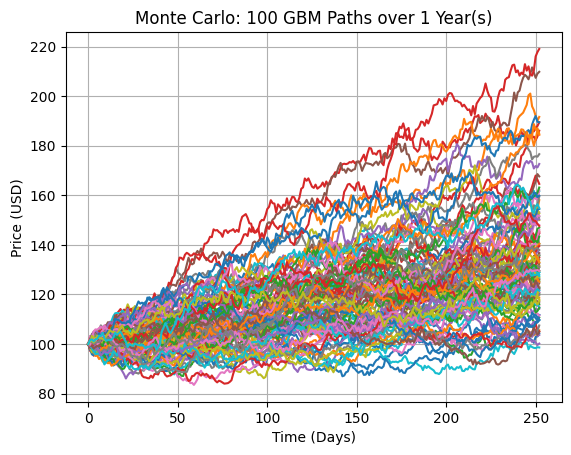

In [5]:
T = 1      # num years
shots = 100
time = int(252 * T)
dt = 1 / 252  # 1 trading day
s0 = 100
mu = 0.34     # expected annual return
sigma = 0.18  # annual volatility

final_prices = []

for shot in range(shots):
    s = s0
    days = [0]
    price = [s0]

    for i in range(time):
        z = quantum_normal_sim()  # replace with normal quantum_normal() if needed, but it takes forever
        s = s * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
        days.append(i + 1)
        price.append(s)

    final_prices.append(s)
    plt.plot(days, price)

plt.xlabel("Time (Days)")
plt.ylabel("Price (USD)")
plt.title(f"Monte Carlo: {shots} GBM Paths over {T} Year(s)")
plt.grid(True)
plt.show()

In [7]:
# Empirical statistics from simulation
gain_count = sum(1 for p in final_prices if p > s0)
empirical_mean = np.mean(final_prices)
empirical_std = np.std(final_prices)

print(f"Chance of gain:  {100 * gain_count / shots:.1f}%")
print(f"Empirical Mean:  ${empirical_mean:.2f}")
print(f"Empirical Std:   ${empirical_std:.2f}")

Chance of gain:  99.0%
Empirical Mean:  $136.69
Empirical Std:   $24.43
